<a href="https://colab.research.google.com/github/Ronald-Tuncar/LAB-06-MDD/blob/develop/lab12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import category_encoders as ce

In [ ]:
df = pd.read_csv('obesidad.csv')
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,21,1.71,131.4,yes,yes,3,3,Sometimes,no,2,no,2,1,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,22,1.75,133.7,yes,yes,3,3,Sometimes,no,2,no,1,1,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,23,1.75,133.7,yes,yes,3,3,Sometimes,no,2,no,1,1,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24,1.74,133.3,yes,yes,3,3,Sometimes,no,3,no,1,1,Sometimes,Public_Transportation,Obesity_Type_III


In [ ]:
# 3. Análisis de datos faltantes
print("Valores faltantes por columna:\n", df.isnull().sum())

Valores faltantes por columna:
 Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


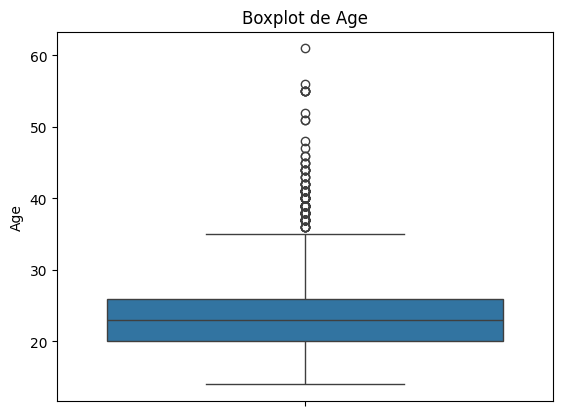

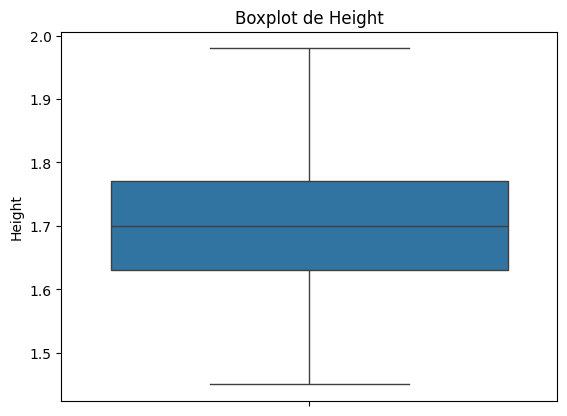

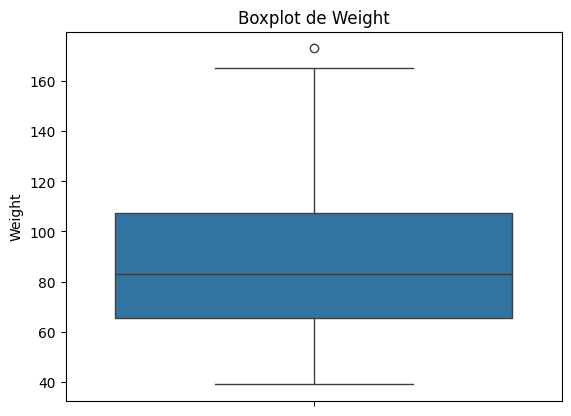

In [ ]:
# 4. Tratamiento de outliers univariado
num_cols = ['Age', 'Height', 'Weight']
for col in num_cols:
    sns.boxplot(df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

In [ ]:
# Método simple para reemplazar outliers con límites IQR
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

for col in num_cols:
  df = remove_outliers_iqr(df, col)

In [ ]:
# 5. Tratamiento de outliers multivariado (Z-score)
from scipy.stats import zscore
df_z = df[num_cols].apply(zscore)
df = df[(np.abs(df_z) < 3).all(axis=1)]

In [ ]:
# 6. Balanceo de clases
print("Distribución original de clases:\n", df['NObeyesdad'].value_counts())
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

Distribución original de clases:
 NObeyesdad
Obesity_Type_III       323
Obesity_Type_I         283
Normal_Weight          280
Insufficient_Weight    271
Overweight_Level_I     271
Obesity_Type_II        268
Overweight_Level_II    254
Name: count, dtype: int64


In [ ]:
# Convertimos categóricas antes del balanceo
encoder = ce.OneHotEncoder(use_cat_names=True)
X_encoded = encoder.fit_transform(X)

In [ ]:
# Balanceo con SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_encoded, y)

print("Distribución balanceada de clases:\n", y_resampled.value_counts())


Distribución balanceada de clases:
 NObeyesdad
Normal_Weight          323
Overweight_Level_I     323
Overweight_Level_II    323
Obesity_Type_I         323
Insufficient_Weight    323
Obesity_Type_II        323
Obesity_Type_III       323
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


In [ ]:
# Escalado solo para GaussianNB
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Modelo GaussianNB
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
y_pred_gnb = gnb.predict(X_test_scaled)
acc_gnb = accuracy_score(y_test, y_pred_gnb)

In [ ]:
mnb = MultinomialNB()
mnb.fit(X_train, y_train)  # sin escalar, pues MultinomialNB no admite negativos
y_pred_mnb = mnb.predict(X_test)
acc_mnb = accuracy_score(y_test, y_pred_mnb)

In [ ]:
print(f"Accuracy GaussianNB: {acc_gnb:.4f}")
print(f"Accuracy MultinomialNB: {acc_mnb:.4f}")

Accuracy GaussianNB: 0.5055
Accuracy MultinomialNB: 0.6556


In [ ]:
# Comparación de modelos
if acc_gnb > acc_mnb:
    print("El modelo GaussianNB obtuvo un mejor desempeño.")
else:
    print("El modelo MultinomialNB obtuvo un mejor desempeño.")

El modelo MultinomialNB obtuvo un mejor desempeño.
